# VLM Pipeline Inspection Notebook

이 노트북은 `detect-and-reason`에 추가한 VLM 분류 파이프라인을 **노트북 안에서 최대한 세부적으로 확인**하기 위한 용도다.

확인 포인트:
- 입력 설정: 이미지, detected bbox, main config, VLM config, CLI
- 중간 계층: normalized input, crop, prompt, backend/generation 파라미터, parser
- 출력: prediction 형식, evaluation/overlay 저장 결과, 반드시 있어야 하는 산출물 / 있으면 좋은 산출물

기본 동작은 **가벼운 inspection / fake backend 기반**이고, 필요할 때 실제 backend 호출을 켤 수 있게 되어 있다.

In [1]:
import os
import sys
import json
import yaml
import shlex
import inspect
import textwrap
from copy import deepcopy
from pathlib import Path
from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown
from PIL import Image, ImageOps

CWD = Path.cwd().resolve()
if (CWD / 'src').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('/home/hyeonjin/detect-and-reason').resolve()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config_loader import load_yaml, resolve_runtime_config
from src.vlm.config import load_vlm_config, derive_output_dir
from src.vlm.normalization import load_or_create_normalized_detections
from src.vlm.cropping import load_crop
from src.vlm.prompting import build_messages
from src.vlm.json_utils import parse_vlm_response
from src.vlm.pipeline import run_vlm_classification_pipeline
from src.vlm.backends.factory import build_vlm_backend
from src.evaluation.vlm_classification_evaluator import evaluate_vlm_classification_predictions

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_colwidth', 160)

def print_section(title: str):
    print('\n' + '=' * 100)
    print(title)
    print('=' * 100)

def yaml_block(data):
    return yaml.safe_dump(data, allow_unicode=True, sort_keys=False)

def serialize_for_notebook(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, Image.Image):
        return f'PIL.Image(size={value.size}, mode={value.mode})'
    if isinstance(value, dict):
        return {k: serialize_for_notebook(v) for k, v in value.items()}
    if isinstance(value, list):
        return [serialize_for_notebook(v) for v in value]
    return value

def preview_messages(messages):
    rows = []
    for idx, message in enumerate(messages):
        row = {'message_index': idx, 'role': message.get('role'), 'items': []}
        for item in message.get('content', []):
            if item.get('type') == 'text':
                row['items'].append({'type': 'text', 'text': item['text']})
            elif item.get('type') == 'image':
                image = item['image']
                row['items'].append({'type': 'image', 'summary': f'PIL.Image(size={image.size}, mode={image.mode})'})
            else:
                row['items'].append(serialize_for_notebook(item))
        rows.append(row)
    return rows

def show_tree(path: Path, max_depth: int = 3):
    path = Path(path)
    if not path.exists():
        print(f'[missing] {path}')
        return
    print(f'[tree] {path}')
    base_depth = len(path.parts)
    for child in sorted(path.rglob('*')):
        depth = len(child.parts) - base_depth
        if depth > max_depth:
            continue
        indent = '  ' * depth
        marker = '/' if child.is_dir() else ''
        print(f'{indent}{child.name}{marker}')

def build_cli_command(model_ref, dataset_ref, vlm_config_ref, split, output_dir_override=None, detector_prediction_dir_override=None):
    parts = [
        './.venv/bin/python',
        'scripts/vlm_classification_pipeline.py',
        '--model', model_ref,
        '--dataset', dataset_ref,
        '--vlm-config', vlm_config_ref,
    ]
    if split:
        parts += ['--split', split]
    if output_dir_override:
        parts += ['--output-dir', str(output_dir_override)]
    if detector_prediction_dir_override:
        parts += ['--detector-prediction-dir', str(detector_prediction_dir_override)]
    return ' '.join(shlex.quote(str(part)) for part in parts)

def artifact_expectations(family: str):
    required = [
        'run_config_input.yaml',
        'normalized_input_detections.json',
        'vlm_results.jsonl',
        'vlm_eval_rows.json',
        'vlm_eval_rows.csv',
        'prediction_class.json',
        'metrics.json',
        'runtime.json',
        'overlay_images',
        'evaluation/confusion_matrix.csv',
        'evaluation/evaluation_results.json',
        'evaluation/per_class_metrics.csv',
        'evaluation/per_image_metrics.csv',
        'evaluation/summary_metrics.csv',
    ]
    wanted = [
        'detector prediction cache reused',
        'single-sample prompt preview visible in notebook',
        'raw response / parsed response preview visible in notebook',
        'artifact tree can be checked directly in notebook',
    ]
    family_specific = 'prediction_class_coco.json' if family in {'rf_detr', 'dino'} else 'prediction_class_yolo/labels'
    return required + [family_specific], wanted

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

/home/hyeonjin/detect-and-reason/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /home/hyeonjin/detect-and-reason


## 1. 입력 설정

여기서 모델 / 데이터셋 / VLM config / split / 출력 위치 / 실제 backend 실행 여부를 제어한다.

- 기본은 `tomatod + rf_detr_1cls + qwen3_vl_4b`
- 기본은 **실제 VLM 호출 없이 inspection 중심**
- `RUN_FULL_PIPELINE=True`로 두면 full pipeline 저장까지 간다
- `USE_FAKE_BACKEND_FOR_PIPELINE=True`면 fake JSON 응답으로 결과 구조만 점검한다

In [23]:
MODEL_REF = 'rf_detr_1cls'
DATASET_REF = 'tomatod'
VLM_CONFIG_REF = 'qwen3_vl_4b'
SPLIT = 'test'

OUTPUT_DIR_OVERRIDE = PROJECT_ROOT / 'notebook' / 'results' / 'vlm_pipeline_demo'
DETECTOR_PREDICTION_DIR_OVERRIDE = None

PREVIEW_INDEX = 0
PREVIEW_COUNT = 5
MAX_SAMPLES = 8
NORMALIZED_REFRESH = False

RUN_SINGLE_RECORD_BACKEND = True
RUN_FULL_PIPELINE = True
USE_FAKE_BACKEND_FOR_PIPELINE = True 
SHOW_LONG_SOURCE = False

FAKE_CLASS_NAME = 'semi-ripe'
FAKE_CATEGORY_ID = 1

CLI_COMMAND = build_cli_command(
    MODEL_REF,
    DATASET_REF,
    VLM_CONFIG_REF,
    SPLIT,
    output_dir_override=OUTPUT_DIR_OVERRIDE,
    detector_prediction_dir_override=DETECTOR_PREDICTION_DIR_OVERRIDE,
)

print_section('Notebook control values')
control_values = {
    'MODEL_REF': MODEL_REF,
    'DATASET_REF': DATASET_REF,
    'VLM_CONFIG_REF': VLM_CONFIG_REF,
    'SPLIT': SPLIT,
    'OUTPUT_DIR_OVERRIDE': str(OUTPUT_DIR_OVERRIDE),
    'DETECTOR_PREDICTION_DIR_OVERRIDE': str(DETECTOR_PREDICTION_DIR_OVERRIDE) if DETECTOR_PREDICTION_DIR_OVERRIDE else None,
    'PREVIEW_INDEX': PREVIEW_INDEX,
    'PREVIEW_COUNT': PREVIEW_COUNT,
    'MAX_SAMPLES': MAX_SAMPLES,
    'NORMALIZED_REFRESH': NORMALIZED_REFRESH,
    'RUN_SINGLE_RECORD_BACKEND': RUN_SINGLE_RECORD_BACKEND,
    'RUN_FULL_PIPELINE': RUN_FULL_PIPELINE,
    'USE_FAKE_BACKEND_FOR_PIPELINE': USE_FAKE_BACKEND_FOR_PIPELINE,
}
pprint(control_values)

print_section('Equivalent CLI command')
print(CLI_COMMAND)


Notebook control values
{'DATASET_REF': 'tomatod',
 'DETECTOR_PREDICTION_DIR_OVERRIDE': None,
 'MAX_SAMPLES': 8,
 'MODEL_REF': 'rf_detr_1cls',
 'NORMALIZED_REFRESH': False,
 'OUTPUT_DIR_OVERRIDE': '/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo',
 'PREVIEW_COUNT': 5,
 'PREVIEW_INDEX': 0,
 'RUN_FULL_PIPELINE': True,
 'RUN_SINGLE_RECORD_BACKEND': True,
 'SPLIT': 'test',
 'USE_FAKE_BACKEND_FOR_PIPELINE': True,
 'VLM_CONFIG_REF': 'qwen3_vl_4b'}

Equivalent CLI command
./.venv/bin/python scripts/vlm_classification_pipeline.py --model rf_detr_1cls --dataset tomatod --vlm-config qwen3_vl_4b --split test --output-dir /home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo


In [15]:
runtime_cfg = resolve_runtime_config(
    model_ref=MODEL_REF,
    dataset_ref=DATASET_REF,
    stage='predict',
    source=SPLIT,
)
dataset_cfg = load_yaml(Path(runtime_cfg['dataset_config_path']))
vlm_cfg, vlm_cfg_path = load_vlm_config(VLM_CONFIG_REF, project_root=runtime_cfg['project_root'])
vlm_cfg = deepcopy(vlm_cfg)
vlm_cfg['input']['refresh_normalized'] = NORMALIZED_REFRESH
vlm_cfg['input']['max_samples'] = MAX_SAMPLES

resolved_output_dir = derive_output_dir(runtime_cfg, output_dir_override=str(OUTPUT_DIR_OVERRIDE))
resolved_prediction_dir = Path(DETECTOR_PREDICTION_DIR_OVERRIDE).resolve() if DETECTOR_PREDICTION_DIR_OVERRIDE else Path(runtime_cfg['paths']['prediction_dir']).resolve()

print_section('Runtime summary')
runtime_summary = {
    'model_name': runtime_cfg['model_name'],
    'family': runtime_cfg['family'],
    'dataset_key': runtime_cfg['dataset']['key'],
    'class_mode': runtime_cfg['class_mode'],
    'pipeline_mode': runtime_cfg['pipeline_mode'],
    'dataset_test_dir': str(runtime_cfg['dataset']['test_dir']),
    'prediction_dir': str(runtime_cfg['paths']['prediction_dir']),
    'qwen_dir': str(runtime_cfg['paths'].get('qwen_dir')) if runtime_cfg['paths'].get('qwen_dir') else None,
    'resolved_prediction_dir_for_this_notebook': str(resolved_prediction_dir),
    'resolved_output_dir_for_this_notebook': str(resolved_output_dir),
}
pprint(runtime_summary)

print_section('Model config YAML (loaded runtime raw)')
print(yaml_block(runtime_cfg['raw']['model']))

print_section('Dataset config YAML (1cls / 3cls variants matter here)')
print(yaml_block(dataset_cfg))

print_section('VLM config YAML (after notebook overrides)')
print(f'vlm_cfg_path = {vlm_cfg_path}')
print(yaml_block(vlm_cfg))


Runtime summary
{'class_mode': '1cls',
 'dataset_key': 'tomatod',
 'dataset_test_dir': '/home/hyeonjin/detect-and-reason/data/yolo/tomatod_1cls/test',
 'family': 'rf_detr',
 'model_name': 'rf_detr_1cls',
 'pipeline_mode': 'detection_reasoning',
 'prediction_dir': '/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction',
 'qwen_dir': '/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_qwen',
 'resolved_output_dir_for_this_notebook': '/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo',
 'resolved_prediction_dir_for_this_notebook': '/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction'}

Model config YAML (loaded runtime raw)
name: rf_detr_1cls
family: rf_detr
framework: rfdetr
class_mode: 1cls
mode: detection_reasoning
model:
  model_size: large
  init_weight: weights/rf-detr-large.pth
class_names:
  0: tomato
train:
  epochs: 150
  imgsz: 640
  batch_size: 4
  gra

## 2. normalized input 만들기 / 로드하기

이 단계는 detector output을 공통 schema JSON으로 맞추는 단계다.

- YOLO 계열: `prediction_dir/labels/*.txt` -> 공통 record 리스트
- COCO 계열: `prediction_dir/<split>/predictions_coco.json` -> 공통 record 리스트
- 이미 캐시가 있으면 `prediction_dir/vlm_cache/<split>_normalized_input_detections.json`을 재사용한다

In [16]:
normalized_bundle, normalized_cache_path, normalized_cache_hit = load_or_create_normalized_detections(
    runtime_cfg=runtime_cfg,
    split=SPLIT,
    prediction_dir=resolved_prediction_dir,
    refresh=NORMALIZED_REFRESH,
)
records = normalized_bundle.get('records', [])

print_section('Normalized detection cache info')
print(f'cache_path = {normalized_cache_path}')
print(f'cache_hit  = {normalized_cache_hit}')
print(f'num_records = {len(records)}')
print(f'normalized_bundle keys = {list(normalized_bundle.keys())}')

if records:
    print_section('First normalized record (raw dict)')
    pprint(records[0])

preview_frame = pd.DataFrame(records[:PREVIEW_COUNT])
display(preview_frame)


Normalized detection cache info
cache_path = /home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/vlm_cache/test_normalized_input_detections.json
cache_hit  = True
num_records = 476
normalized_bundle keys = ['schema_version', 'detector_family', 'model_name', 'dataset_key', 'source_prediction_dir', 'source_image_root', 'source_prediction_coco', 'source_gt_coco', 'records', 'image_ids']

First normalized record (raw dict)
{'bbox_xywh': [572.6967163085938,
               482.447998046875,
               38.6514892578125,
               37.51458740234375],
 'bbox_xyxy': [572.6967163085938,
               482.447998046875,
               611.3482055664062,
               519.9625854492188],
 'bbox_yolo': [0.740028076171875,
               0.6265066146850586,
               0.048314361572265624,
               0.04689323425292969],
 'det_score': 0.873290479183197,
 'detection_index': 0,
 'detector_class_id': 0,
 'detector_class_name': 'tomato',
 'file_

,record_id,image_id,file_name,image_path,image_width,image_height,source_format,source_prediction_path,bbox_xyxy,bbox_xywh,bbox_yolo,det_score,detector_class_id,detector_class_name,detection_index
0,stereo20190406_054921_p0_snap_122#0,1,stereo20190406_054921_p0_snap_122.jpg,/home/hyeonjin/detect-and-reason/data/yolo/tomatod_1cls/test/images/stereo20190406_054921_p0_snap_122.jpg,800,800,coco_json,/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/test/predictions_coco.json,"[572.6967163085938, 482.447998046875, 611.3482055664062, 519.9625854492188]","[572.6967163085938, 482.447998046875, 38.6514892578125, 37.51458740234375]","[0.740028076171875, 0.6265066146850586, 0.048314361572265624, 0.04689323425292969]",0.873290,0,tomato,0
1,stereo20190406_054921_p0_snap_122#1,1,stereo20190406_054921_p0_snap_122.jpg,/home/hyeonjin/detect-and-reason/data/yolo/tomatod_1cls/test/images/stereo20190406_054921_p0_snap_122.jpg,800,800,coco_json,/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/test/predictions_coco.json,"[169.02418518066406, 513.168212890625, 201.84271240234375, 546.7683715820312]","[169.02418518066406, 513.168212890625, 32.81852722167969, 33.60015869140625]","[0.23179181098937987, 0.6624603652954102, 0.04102315902709961, 0.042000198364257814]",0.866179,0,tomato,1
2,stereo20190406_054921_p0_snap_122#2,1,stereo20190406_054921_p0_snap_122.jpg,/home/hyeonjin/detect-and-reason/data/yolo/tomatod_1cls/test/images/stereo20190406_054921_p0_snap_122.jpg,800,800,coco_json,/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/test/predictions_coco.json,"[434.96575927734375, 645.6394653320312, 467.0460205078125, 678.1235961914062]","[434.96575927734375, 645.6394653320312, 32.08026123046875, 32.484130859375]","[0.5637573623657226, 0.8273519134521484, 0.040100326538085936, 0.04060516357421875]",0.863476,0,tomato,2
3,stereo20190406_054921_p0_snap_122#3,1,stereo20190406_054921_p0_snap_122.jpg,/home/hyeonjin/detect-and-reason/data/yolo/tomatod_1cls/test/images/stereo20190406_054921_p0_snap_122.jpg,800,800,coco_json,/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/test/predictions_coco.json,"[573.5772094726562, 342.45947265625, 619.6785888671875, 387.8857727050781]","[573.5772094726562, 342.45947265625, 46.10137939453125, 45.426300048828125]","[0.7457848739624023, 0.4564657783508301, 0.05762672424316406, 0.05678287506103516]",0.852864,0,tomato,3
4,stereo20190406_054921_p0_snap_122#4,1,stereo20190406_054921_p0_snap_122.jpg,/home/hyeonjin/detect-and-reason/data/yolo/tomatod_1cls/test/images/stereo20190406_054921_p0_snap_122.jpg,800,800,coco_json,/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/test/predictions_coco.json,"[112.54586791992188, 565.6268310546875, 142.20709228515625, 594.39501953125]","[112.54586791992188, 565.6268310546875, 29.661224365234375, 28.7681884765625]","[0.15922060012817382, 0.725013656616211, 0.037076530456542967, 0.035960235595703126]",0.840293,0,tomato,4



Selected normalized record
{'bbox_xywh': [572.6967163085938,
               482.447998046875,
               38.6514892578125,
               37.51458740234375],
 'bbox_xyxy': [572.6967163085938,
               482.447998046875,
               611.3482055664062,
               519.9625854492188],
 'bbox_yolo': [0.740028076171875,
               0.6265066146850586,
               0.048314361572265624,
               0.04689323425292969],
 'det_score': 0.873290479183197,
 'detection_index': 0,
 'detector_class_id': 0,
 'detector_class_name': 'tomato',
 'file_name': 'stereo20190406_054921_p0_snap_122.jpg',
 'image_height': 800,
 'image_id': 1,
 'image_path': '/home/hyeonjin/detect-and-reason/data/yolo/tomatod_1cls/test/images/stereo20190406_054921_p0_snap_122.jpg',
 'image_width': 800,
 'record_id': 'stereo20190406_054921_p0_snap_122#0',
 'source_format': 'coco_json',
 'source_prediction_path': '/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/t

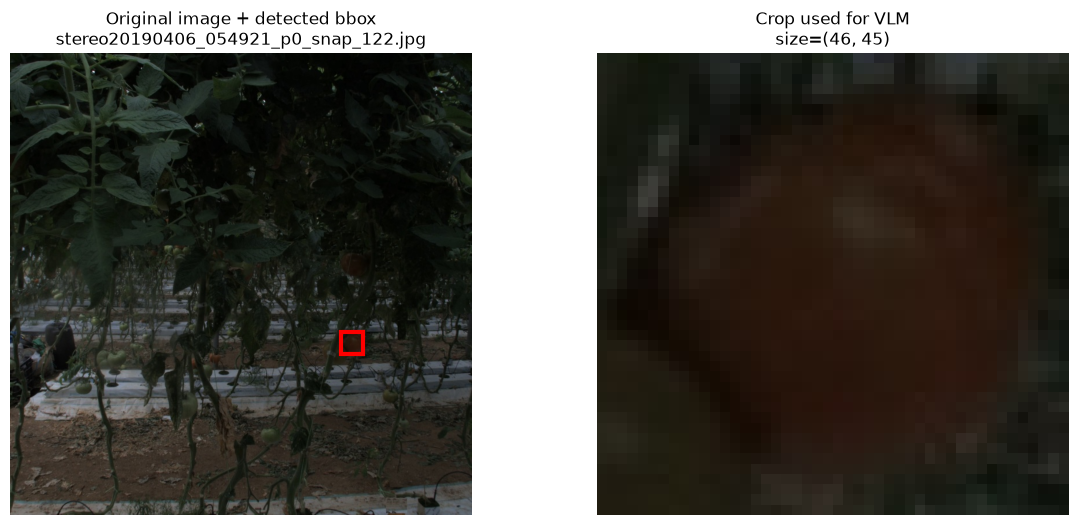

In [17]:
assert records, 'normalized input records are empty'
selected_record = records[PREVIEW_INDEX]
crop_cfg = vlm_cfg.get('crop', {})
selected_crop = load_crop(
    selected_record,
    expand_ratio=float(crop_cfg.get('expand_ratio', 0.1)),
    min_size=int(crop_cfg.get('min_size', 32)),
)

print_section('Selected normalized record')
pprint(selected_record)

image_path = Path(selected_record['image_path'])
with Image.open(image_path) as handle:
    original_image = ImageOps.exif_transpose(handle).convert('RGB')

x1, y1, x2, y2 = [float(v) for v in selected_record['bbox_xyxy']]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(original_image)
axes[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=3, edgecolor='red'))
axes[0].set_title(f'Original image + detected bbox\n{selected_record["file_name"]}')
axes[0].axis('off')

axes[1].imshow(selected_crop)
axes[1].set_title(f'Crop used for VLM\nsize={selected_crop.size}')
axes[1].axis('off')
plt.show()

## 3. prompt / message 구성 확인

여기서는 실제로 VLM에 들어가는 `messages` 구조를 확인한다.

- system message
- reference example message들 (있으면)
- 최종 user message의 text / image / instruction
- bbox JSON이 prompt에 어떻게 삽입되는지

In [18]:
prompt_cfg = vlm_cfg.get('prompt', {})
messages = build_messages(
    record=selected_record,
    crop_image=selected_crop,
    prompt_cfg=prompt_cfg,
)

print_section('Message preview (image objects summarized)')
for row in preview_messages(messages):
    pprint(row)
    print('-' * 100)

print_section('Final user instruction text only')
final_user_instruction = messages[-1]['content'][-1]['text']
print(final_user_instruction)

print_section('Prompt config used for this record')
pprint(prompt_cfg)


Message preview (image objects summarized)
{'items': [{'text': 'You classify tomato ripeness from a detector crop. Always '
                    'return strict JSON only. Do not add markdown or extra '
                    'text.',
            'type': 'text'}],
 'message_index': 0,
 'role': 'system'}
----------------------------------------------------------------------------------------------------
{'items': [{'text': 'Target crop image of one detected tomato.',
            'type': 'text'},
           {'summary': 'PIL.Image(size=(46, 45), mode=RGB)', 'type': 'image'},
           {'text': 'Classify only the tomato shown in the crop image.\n'
                    'Use the crop appearance as primary evidence.\n'
                    '\n'
                    'Input bbox JSON (copy these values exactly into '
                    'output.bbox): {"x1": 572.7, "y1": 482.45, "x2": 611.35, '
                    '"y2": 519.96}\n'
                    '\n'
                    'Ripeness guide:\n'
    

## 4. 중간 계층: 함수 시그니처 / 코드 흐름 확인

필요하면 `SHOW_LONG_SOURCE=True`로 두고 관련 함수들의 실제 소스도 바로 확인할 수 있다.

In [19]:
functions_to_check = [
    load_or_create_normalized_detections,
    load_crop,
    build_messages,
    parse_vlm_response,
    evaluate_vlm_classification_predictions,
    run_vlm_classification_pipeline,
]

print_section('Function signatures')
for fn in functions_to_check:
    print(f'{fn.__name__}{inspect.signature(fn)}')

if SHOW_LONG_SOURCE:
    for fn in functions_to_check:
        print_section(f'SOURCE: {fn.__name__}')
        print(inspect.getsource(fn))
else:
    print_section('Long source is skipped by default')
    print('Set SHOW_LONG_SOURCE = True and run this cell again if you want full source prints.')


Function signatures
load_or_create_normalized_detections(*, runtime_cfg: 'dict[str, Any]', split: 'str', prediction_dir: 'Path', refresh: 'bool' = False) -> 'tuple[dict[str, Any], Path, bool]'
load_crop(record: 'dict', *, expand_ratio: 'float' = 0.1, min_size: 'int' = 32) -> 'Image.Image'
build_messages(*, record: 'dict[str, Any]', crop_image: 'Image.Image', prompt_cfg: 'dict[str, Any]') -> 'list[dict[str, Any]]'
parse_vlm_response(*, text: 'str', bbox_fallback_xyxy: 'list[float]', require_reasoning: 'bool') -> 'dict[str, Any]'
evaluate_vlm_classification_predictions(*, gt_images_dir: 'str | Path', gt_labels_dir: 'str | Path', predictions: 'list[dict[str, Any]]', class_names: 'dict[int, str] | list[str] | None' = None, iou_threshold: 'float' = 0.5) -> 'dict[str, Any]'
run_vlm_classification_pipeline(*, runtime_cfg: 'dict[str, Any]', dataset_cfg: 'dict[str, Any]', vlm_cfg: 'dict[str, Any]', output_dir_override: 'str | None' = None, split_override: 'str | None' = None, detector_predicti

## 5. backend / generation 파라미터 / parser 확인

기본은 실제 VLM을 부르지 않고, fake JSON 응답을 parser에 넣어서 **출력 형식이 어떻게 해석되는지** 먼저 확인한다.

원하면 `RUN_SINGLE_RECORD_BACKEND=True`로 바꿔 실제 backend를 1건만 호출할 수 있다.

In [20]:
backend_cfg = vlm_cfg.get('backend', {})
generation_cfg = vlm_cfg.get('generation', {})

print_section('Backend config')
pprint(backend_cfg)

print_section('Generation config')
pprint(generation_cfg)

fake_response = json.dumps({
    'class_name': FAKE_CLASS_NAME,
    'category_id': FAKE_CATEGORY_ID,
    'bbox': {
        'x1': selected_record['bbox_xyxy'][0],
        'y1': selected_record['bbox_xyxy'][1],
        'x2': selected_record['bbox_xyxy'][2],
        'y2': selected_record['bbox_xyxy'][3],
    },
    'reasoning': 'notebook fake response preview',
}, ensure_ascii=False)

print_section('Fake response text -> parser output')
print(fake_response)
parsed_fake = parse_vlm_response(
    text=fake_response,
    bbox_fallback_xyxy=[float(v) for v in selected_record['bbox_xyxy']],
    require_reasoning=bool(prompt_cfg.get('use_reasoning', True)),
)
pprint(parsed_fake)

if RUN_SINGLE_RECORD_BACKEND:
    print_section('Running actual backend on a single record')
    backend = build_vlm_backend(backend_cfg=backend_cfg, generation_cfg=generation_cfg)
    raw_response = backend.generate(messages)
    print(raw_response)
    parsed_real = parse_vlm_response(
        text=raw_response,
        bbox_fallback_xyxy=[float(v) for v in selected_record['bbox_xyxy']],
        require_reasoning=bool(prompt_cfg.get('use_reasoning', True)),
    )
    print_section('Parsed single-record backend output')
    pprint(parsed_real)
else:
    print_section('Actual backend call is skipped')
    print('Set RUN_SINGLE_RECORD_BACKEND = True if you want to call the configured VLM once.')


Backend config
{'api_key_env': 'OPENAI_API_KEY',
 'batch_size': 1,
 'compile_model': False,
 'device_map': 'auto',
 'model_name': 'Qwen/Qwen3-VL-4B-Instruct',
 'torch_dtype': 'auto',
 'trust_remote_code': True,
 'type': 'qwen_hf',
 'use_4bit': True}

Generation config
{'do_sample': False,
 'max_new_tokens': 220,
 'repetition_penalty': 1.1,
 'temperature': 0.2,
 'top_k': 40,
 'top_p': 0.9}

Fake response text -> parser output
{"class_name": "semi-ripe", "category_id": 1, "bbox": {"x1": 572.6967163085938, "y1": 482.447998046875, "x2": 611.3482055664062, "y2": 519.9625854492188}, "reasoning": "notebook fake response preview"}
{'bbox_xyxy': [572.6967163085938,
               482.447998046875,
               611.3482055664062,
               519.9625854492188],
 'class_id': 1,
 'class_name': 'semi-ripe',
 'ok': True,
 'parse_error': None,
 'parsed_payload': {'bbox': {'x1': 572.6967163085938,
                             'x2': 611.3482055664062,
                             'y1': 482.447998

## 6. full pipeline 실행 옵션

여기서는 실제 `run_vlm_classification_pipeline(...)`을 끝까지 돌린다.

- `RUN_FULL_PIPELINE=False`면 실행하지 않음
- `USE_FAKE_BACKEND_FOR_PIPELINE=True`면 fake backend로 prediction/eval/overlay/result structure만 확인
- 실제 backend를 쓰려면 `RUN_FULL_PIPELINE=True` and `USE_FAKE_BACKEND_FOR_PIPELINE=False`

In [24]:
pipeline_result = None

if RUN_FULL_PIPELINE:
    import src.vlm.pipeline as pipeline_mod

    original_factory = pipeline_mod.build_vlm_backend
    try:
        if USE_FAKE_BACKEND_FOR_PIPELINE:
            class FakeNotebookBackend:
                supports_batch = True
                def generate_batch(self, messages_batch):
                    payload = json.dumps({
                        'class_name': FAKE_CLASS_NAME,
                        'category_id': FAKE_CATEGORY_ID,
                        'reasoning': 'notebook fake backend full-pipeline response',
                    }, ensure_ascii=False)
                    return [payload] * len(messages_batch)

            pipeline_mod.build_vlm_backend = lambda **kwargs: FakeNotebookBackend()
            print('[info] Fake backend is patched into src.vlm.pipeline.build_vlm_backend')

        pipeline_result = pipeline_mod.run_vlm_classification_pipeline(
            runtime_cfg=runtime_cfg,
            dataset_cfg=dataset_cfg,
            vlm_cfg=vlm_cfg,
            output_dir_override=str(OUTPUT_DIR_OVERRIDE),
            split_override=SPLIT,
            detector_prediction_dir_override=str(DETECTOR_PREDICTION_DIR_OVERRIDE) if DETECTOR_PREDICTION_DIR_OVERRIDE else None,
        )
    finally:
        pipeline_mod.build_vlm_backend = original_factory

    print_section('Pipeline result summary')
    pprint(serialize_for_notebook(pipeline_result))
else:
    print_section('Full pipeline run is skipped')
    print('Set RUN_FULL_PIPELINE = True and rerun this cell when you want artifacts to be written.')

[info] Fake backend is patched into src.vlm.pipeline.build_vlm_backend

Pipeline result summary
{'metrics': {'classification_acc': 0.0,
             'correct_class_matches': 0,
             'detection_acc': 0.014957264957264958,
             'iou_threshold': 0.5,
             'matched_detections': 7,
             'num_images': 55,
             'overall_acc': 0.0,
             'overall_f1': 0.0,
             'overall_precision': 0.0,
             'overall_recall': 0.0,
             'total_ground_truths': 468,
             'total_predictions': 8},
 'output_dir': '/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo',
 'runtime': {'backend': {'batch_size': 1,
                         'model_name': 'Qwen/Qwen3-VL-4B-Instruct',
                         'type': 'qwen_hf'},
             'dataset_key': 'tomatod',
             'elapsed_sec': 0.125,
             'family_export': {'exported': 8,
                               'prediction_class_coco': '/home/hyeonjin/detect-and-reas

## 7. 출력 형식 / 결과 저장 / 원하는 결과 체크

여기서는 산출물 tree와 필수/희망 결과를 같이 확인한다.

- 반드시 있어야 하는 결과: 요청한 JSON/CSV/runtime/overlay/evaluation 산출물
- 있길 바라는 결과: cache 재사용, prompt/raw response 확인 가능, artifact tree 즉시 확인 가능

In [25]:
family = runtime_cfg['family']
required_outputs, wanted_outputs = artifact_expectations(family)
final_output_dir = Path(OUTPUT_DIR_OVERRIDE).resolve()

print_section('Wanted results: must-have')
for item in required_outputs:
    print(f'- {item}')

print_section('Wanted results: nice-to-have')
for item in wanted_outputs:
    print(f'- {item}')

print_section('Artifact tree (if output dir exists)')
show_tree(final_output_dir, max_depth=4)

status_rows = []
for item in required_outputs:
    path = final_output_dir / item
    status_rows.append({
        'artifact': item,
        'exists': path.exists(),
        'path': str(path),
    })

print_section('Required artifact status table')
display(pd.DataFrame(status_rows))

metrics_path = final_output_dir / 'metrics.json'
if metrics_path.exists():
    print_section('metrics.json')
    pprint(json.loads(metrics_path.read_text(encoding='utf-8')))

runtime_json_path = final_output_dir / 'runtime.json'
if runtime_json_path.exists():
    print_section('runtime.json')
    pprint(json.loads(runtime_json_path.read_text(encoding='utf-8')))

eval_rows_path = final_output_dir / 'vlm_eval_rows.json'
if eval_rows_path.exists():
    print_section('First 5 eval rows')
    eval_rows = json.loads(eval_rows_path.read_text(encoding='utf-8'))
    display(pd.DataFrame(eval_rows[:5]))


Wanted results: must-have
- run_config_input.yaml
- normalized_input_detections.json
- vlm_results.jsonl
- vlm_eval_rows.json
- vlm_eval_rows.csv
- prediction_class.json
- metrics.json
- runtime.json
- overlay_images
- evaluation/confusion_matrix.csv
- evaluation/evaluation_results.json
- evaluation/per_class_metrics.csv
- evaluation/per_image_metrics.csv
- evaluation/summary_metrics.csv
- prediction_class_coco.json

Wanted results: nice-to-have
- detector prediction cache reused
- single-sample prompt preview visible in notebook
- raw response / parsed response preview visible in notebook
- artifact tree can be checked directly in notebook

Artifact tree (if output dir exists)
[tree] /home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo
  evaluation/
    confusion_matrix.csv
    evaluation_results.json
    per_class_metrics.csv
    per_image_metrics.csv
    summary_metrics.csv
  metrics.json
  normalized_input_detections.json
  overlay_images/
    stereo20190405_132743_

,artifact,exists,path
0,run_config_input.yaml,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/run_config_input.yaml
1,normalized_input_detections.json,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/normalized_input_detections.json
2,vlm_results.jsonl,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/vlm_results.jsonl
3,vlm_eval_rows.json,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/vlm_eval_rows.json
4,vlm_eval_rows.csv,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/vlm_eval_rows.csv
5,prediction_class.json,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/prediction_class.json
6,metrics.json,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/metrics.json
7,runtime.json,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/runtime.json
8,overlay_images,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/overlay_images
9,evaluation/confusion_matrix.csv,True,/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/evaluation/confusion_matrix.csv



metrics.json
{'classification_acc': 0.0,
 'correct_class_matches': 0,
 'detection_acc': 0.014957264957264958,
 'iou_threshold': 0.5,
 'matched_detections': 7,
 'num_images': 55,
 'overall_acc': 0.0,
 'overall_f1': 0.0,
 'overall_precision': 0.0,
 'overall_recall': 0.0,
 'total_ground_truths': 468,
 'total_predictions': 8}

runtime.json
{'backend': {'batch_size': 1,
             'model_name': 'Qwen/Qwen3-VL-4B-Instruct',
             'type': 'qwen_hf'},
 'dataset_key': 'tomatod',
 'elapsed_sec': 0.125,
 'family_export': {'exported': 8,
                   'prediction_class_coco': '/home/hyeonjin/detect-and-reason/notebook/results/vlm_pipeline_demo/prediction_class_coco.json'},
 'model_name': 'rf_detr_1cls',
 'normalized_cache_hit': True,
 'normalized_cache_path': '/home/hyeonjin/detect-and-reason/result/detection_reasoning/tomatod/rf_detr_1cls_prediction/vlm_cache/test_normalized_input_detections.json',
 'num_input_detections': 8,
 'num_vlm_results': 8,
 'output_dir': '/home/hyeonjin/de

,row_type,stem,file_name,gt_class_id,gt_class_name,pred_class_id,pred_class_name,iou,detection_correct,classification_correct,det_score,reasoning,record_id,parse_error
0,miss,stereo20190405_132743_p0_snap_514,stereo20190405_132743_p0_snap_514.jpg,2,unripe,-1,none,0.0,False,False,None,,None,None
1,miss,stereo20190405_132743_p0_snap_514,stereo20190405_132743_p0_snap_514.jpg,2,unripe,-1,none,0.0,False,False,None,,None,None
2,miss,stereo20190405_132743_p0_snap_514,stereo20190405_132743_p0_snap_514.jpg,2,unripe,-1,none,0.0,False,False,None,,None,None
3,miss,stereo20190405_132743_p0_snap_514,stereo20190405_132743_p0_snap_514.jpg,0,fully-ripe,-1,none,0.0,False,False,None,,None,None
4,miss,stereo20190405_132743_p0_snap_514,stereo20190405_132743_p0_snap_514.jpg,2,unripe,-1,none,0.0,False,False,None,,None,None
